In [ ]:
#PART B + PART E (PARTIAL) + PART F

In [1]:
%pip install -q google-cloud-translate==3.15.3 protobuf==4.25.3

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Install python-dotenv (quietly), then import and continue
import sys, subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "python-dotenv"])

print("python-dotenv successfully installed. Continue to run the next cell.")


python-dotenv successfully installed. Continue to run the next cell.


In [3]:
# Sanity check to see if Google API Translate is successfully installed in the kernel
import os, pathlib, sys, json, importlib

print("Kernel Python:", sys.executable)  # make sure this matches your conda env 
print("GOOGLE_CLOUD_PROJECT =", os.getenv("GOOGLE_CLOUD_PROJECT"))
key = os.getenv("GOOGLE_APPLICATION_CREDENTIALS")
print("GOOGLE_APPLICATION_CREDENTIALS =", key)
print("Key file exists? ->", (pathlib.Path(key).exists() if key else None))

# Optional check of the key to confirm project_id
if key and pathlib.Path(key).exists():
    try:
        info = json.load(open(key))
        print("Key project_id =", info.get("project_id"))
    except Exception as e:
        print("Couldn't read key JSON:", e)

# Check the library is installed in THIS kernel
try:
    import google.cloud.translate_v3 as translate
    print("google-cloud-translate import: OK")
except Exception as e:
    print("google-cloud-translate import error:", e)


Kernel Python: C:\Users\Busisiwe\vproject\Scripts\python.exe
GOOGLE_CLOUD_PROJECT = None
GOOGLE_APPLICATION_CREDENTIALS = None
Key file exists? -> None
google-cloud-translate import: OK


In [4]:
import os, pathlib, sys, subprocess

os.environ["GOOGLE_CLOUD_PROJECT"] = "inf791-translate"
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "/home/taongashe-muzvidziwa/Downloads/inf791-translate-9d9fa523e40e.json"

# (re)install client in this kernel if needed
try:
    import google.cloud.translate_v3 as translate
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "google-cloud-translate==3.15.3", "protobuf==4.25.3"])
    import google.cloud.translate_v3 as translate

print("Set env vars in-process; re-run the translator guard cell now.")


Set env vars in-process; re-run the translator guard cell now.


In [5]:
# Bootstrap environment and folders 
import os, pathlib, pandas as pd

ROOT = pathlib.Path.cwd()
DATA = ROOT / "data"
CACHE = ROOT / "cache"
RESULTS = ROOT / "results"

for p in (DATA, CACHE, RESULTS):
    p.mkdir(exist_ok=True)

# Optional: load .env if available
from dotenv import load_dotenv
if (ROOT / ".env").exists():
    load_dotenv(ROOT / ".env")
    print("Loaded .env successfully")
else:
    print("No .env file found (running in fallback mode)")

print(f"ROOT: {ROOT}")
print("Data folder →", DATA.exists())
print("Cache folder →", CACHE.exists())
print("Results folder →", RESULTS.exists())

print("Bootstrap OK")


No .env file found (running in fallback mode)
ROOT: C:\Users\Busisiwe\Downloads\791-Group-Assignment-main (2)\791-Group-Assignment-main\791-Group-Assignment-main
Data folder → True
Cache folder → True
Results folder → True
Bootstrap OK


In [6]:
# Translator guard with automatic fallback
import os, sys, subprocess, pathlib

# try to see if user already set google cloud creds
GOOGLE_PROJECT = os.getenv("GOOGLE_CLOUD_PROJECT", "").strip()
GOOGLE_KEY     = os.getenv("GOOGLE_APPLICATION_CREDENTIALS", "").strip()

USE_GOOGLE_API = False
USE_DEEP_TRANS = False

# check if google credentials exist
if GOOGLE_PROJECT and GOOGLE_KEY and pathlib.Path(GOOGLE_KEY).exists():
    try:
        from google.cloud import translate_v3 as translate
        USE_GOOGLE_API = True
        print("Using official Google Cloud Translate API")
    except Exception:
        print("Google Cloud library missing — falling back to deep-translator")
else:
    print("No Google credentials found, using Deep-Translator (free API)")

# install deep-translator if missing
try:
    from deep_translator import GoogleTranslator
    USE_DEEP_TRANS = not USE_GOOGLE_API
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "deep-translator"])
    from deep_translator import GoogleTranslator
    USE_DEEP_TRANS = not USE_GOOGLE_API

def translate_texts(texts, target="en", source="auto"):
    """Translates a list of words either through Google Cloud or Deep-Translator."""
    if not texts:
        return []
    results = []
    if USE_GOOGLE_API:
        from google.cloud import translate_v3 as translate
        client = translate.TranslationServiceClient()
        parent = f"projects/{GOOGLE_PROJECT}/locations/global"
        for t in texts:
            try:
                resp = client.translate_text(contents=[t], target_language_code=target, parent=parent)
                results.append(resp.translations[0].translated_text)
            except Exception as e:
                print("GCP error, keeping original:", t, "-", str(e)[:80])
                results.append(t)
    else:
        tr = GoogleTranslator(source=source, target=target)
        for t in texts:
            try:
                results.append(tr.translate(t))
            except Exception:
                results.append(t)
    return results

print("Translator ready",
      "| Mode:", "Google API" if USE_GOOGLE_API else "Deep-Translator (free)")


No Google credentials found, using Deep-Translator (free API)
Translator ready | Mode: Deep-Translator (free)


In [51]:
#Parameters and inputs
import pandas as pd
import numpy as np

BASE_LEXICON_XLSX = "expanded_lexicon_v4.xlsx"
LEX_WORK          = "expanded_lexicon_v4_working.xlsx"
CORPUS_CSV        = DATA / "shona_senti.csv"

MIN_TOKEN_FREQ    = 5
TOP_N_PER_CLASS   = 300

assert (ROOT/BASE_LEXICON_XLSX).exists(), "Missing expanded_lexicon_v4.xlsx in project root."
assert (CORPUS_CSV).exists(), "Missing data/shona_senti.csv"

print("Inputs OK")


Inputs OK


In [8]:
# === PART E + F (Safe Unified Version) ===
# Cleaning, Tokenising, Hybrid Correction (Google Translate), PMI, and Lexicon prep

from pathlib import Path
import re, math, time
from collections import Counter, defaultdict
from tqdm import tqdm
import pandas as pd
import numpy as np

# === Google Translate (Deep Translator) ===
try:
    from deep_translator import GoogleTranslator
    translator = GoogleTranslator(source="auto", target="en")
    print("✅ Using Deep Translator (Google Translate API)")
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "deep-translator"])
    from deep_translator import GoogleTranslator
    translator = GoogleTranslator(source="auto", target="en")
    print("✅ Installed and using Deep Translator")

# === Paths and parameters ===
ROOT = Path(".")
DATA = ROOT / "data"
RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)

CORPUS_CSV = DATA / "shona_senti.csv"
BASE_LEXICON_XLSX = ROOT / "expanded_lexicon_v4.xlsx"
LEX_WORK = ROOT / "expanded_lexicon_v4_working.xlsx"

MIN_TOKEN_FREQ = 5
TOP_N_PER_CLASS = 300

assert CORPUS_CSV.exists(), f"❌ Missing file: {CORPUS_CSV}"
print("✅ Using corpus:", CORPUS_CSV)

# === Regex and cleaner ===
PUNCT_RE = re.compile(r"[\.,!?:;\-—_\(\)\[\]\{\}\"\'`\/\\]")
MULTISPACE_RE = re.compile(r"\s+")

def clean_text(s: str) -> str:
    if not isinstance(s, str):
        return ""
    s = s.lower()
    s = PUNCT_RE.sub(" ", s)
    s = MULTISPACE_RE.sub(" ", s).strip()
    return s

def tokenize(s: str):
    return [t for t in s.split() if t]

# === SAFE Google Translation Correction (with auto-save) ===
def safe_translate(text):
    """Translate text safely; return original if it fails."""
    try:
        return translator.translate(text)
    except Exception:
        return text

def hybrid_correction_batched(df, batch_size=200):
    """Process and save translation every N rows to avoid data loss."""
    translated = []
    for i, text in enumerate(tqdm(df["text_clean"], desc="Translating...")):
        corrected = safe_translate(text)
        translated.append(corrected)

        # auto-save every 200 rows
        if (i + 1) % batch_size == 0:
            df_partial = df.iloc[:i+1].copy()
            df_partial["text_hybrid"] = translated
            df_partial.to_csv("auto_partial_translation.csv", index=False)
            print(f"💾 Auto-saved progress at row {i+1}/{len(df)}")
            time.sleep(5)  # brief cooldown for API

    return translated

# === Load data ===
df = pd.read_csv(CORPUS_CSV).dropna(subset=["text", "label"])
df["text_clean"] = df["text"].map(clean_text)

print("🚀 Running Google Translate hybrid correction safely...")
df["text_hybrid"] = hybrid_correction_batched(df)

# === Save corrections for manual/native review ===
review_df = df[df["text_clean"] != df["text_hybrid"]][["text_clean", "text_hybrid"]]
review_df.to_csv("review_queue_spelling.csv", index=False)
print(f"✅ Saved {len(review_df)} corrected text pairs for manual review.")

# === Tokenisation ===
df["tokens"] = df["text_hybrid"].map(tokenize)
df.to_csv(RESULTS / "cleaned_corpus.csv", index=False)
print(f"✅ Saved cleaned corpus → {RESULTS / 'cleaned_corpus.csv'}")

print("Corpus shape:", df.shape)
print("Label distribution:\n", df["label"].value_counts())

# === PMI Computation ===
def compute_class_pmi(df, tokens_col="tokens", label_col="label", min_freq=5):
    total = Counter(); by_cls = defaultdict(Counter)
    for _, r in df[[tokens_col, label_col]].iterrows():
        toks, lbl = r[tokens_col], r[label_col]
        total.update(toks); by_cls[lbl].update(toks)
    vocab = {w for w, c in total.items() if c >= min_freq}
    if not vocab:
        return pd.DataFrame(columns=["token","label","PMI","freq","class_freq"])
    total_sum = sum(total[w] for w in vocab)
    cls_sums = {c: sum(by_cls[c][w] for w in vocab) for c in by_cls}
    rows = []
    for w in vocab:
        p_w = (total[w]+1)/(total_sum+len(vocab))
        for c in by_cls:
            p_joint = (by_cls[c][w]+1)/(cls_sums[c]+len(vocab))
            p_c = (cls_sums[c]+len(vocab))/(total_sum+len(vocab))
            pmi = math.log2(p_joint/(p_w*p_c))
            rows.append({"token":w,"label":c,"PMI":pmi,"freq":total[w],"class_freq":by_cls[c][w]})
    return pd.DataFrame(rows).sort_values(["label","PMI"], ascending=[True,False])

print("📊 Computing PMI...")
pmi_df = compute_class_pmi(df, tokens_col="tokens", label_col="label", min_freq=MIN_TOKEN_FREQ)
cands = (pmi_df.groupby("label", group_keys=False)
                .apply(lambda g: g.nlargest(TOP_N_PER_CLASS, "PMI"))
                .reset_index(drop=True))
cands.to_csv(RESULTS / "pmi_candidates.csv", index=False)
print("✅ Saved:", RESULTS / "pmi_candidates.csv", cands.shape)

# === Merge PMI + polarity ===
best = (cands.sort_values("PMI", ascending=False)
              .groupby("token").first().reset_index())
label2sign = {"positive":1,"pos":1,"negative":-1,"neg":-1,"neutral":0,"neu":0}
best["pmi_sign"] = best["label"].str.lower().map(label2sign).fillna(0)

# === Lexicon setup ===
lex_src = pd.read_excel(BASE_LEXICON_XLSX)
lex_src.columns = [str(c).strip() for c in lex_src.columns]
for col in ["French","English","Zulu","Xhosa","Sepedi","Shona","Afrikaans"]:
    if col not in lex_src.columns:
        lex_src[col] = np.nan

if LEX_WORK.exists():
    lex_src = pd.read_excel(LEX_WORK)
    print("Loaded working copy:", LEX_WORK)
else:
    lex_src.to_excel(LEX_WORK, index=False)
    print("Created working copy:", LEX_WORK)

lex = lex_src.copy()
if "Score" in lex.columns:
    lex["polarity_sign"] = np.sign(pd.to_numeric(lex["Score"], errors="coerce")).fillna(0)
elif "Sentiment" in lex.columns:
    m = {"positive":1,"pos":1,"negative":-1,"neg":-1,"neutral":0,"neu":0}
    lex["polarity_sign"] = lex["Sentiment"].astype(str).str.lower().map(m).fillna(0)
else:
    lex["polarity_sign"] = 0

print("✅ Lexicon setup complete.")


✅ Using Deep Translator (Google Translate API)
✅ Using corpus: data\shona_senti.csv
🚀 Running Google Translate hybrid correction safely...


Translating...:   1%|▋                                                           | 199/15959 [04:55<6:00:52,  1.37s/it]

💾 Auto-saved progress at row 200/15959


Translating...:   3%|█▌                                                          | 399/15959 [09:54<7:52:50,  1.82s/it]

💾 Auto-saved progress at row 400/15959


...

💾 Auto-saved progress at row 15800/15959


Translating...: 100%|██████████████████████████████████████████████████████████| 15959/15959 [7:26:39<00:00,  1.68s/it]


✅ Saved 15159 corrected text pairs for manual review.
✅ Saved cleaned corpus → results\cleaned_corpus.csv
Corpus shape: (15959, 6)
Label distribution:
 label
negative    7820
positive    4744
neutral     3395
Name: count, dtype: int64
📊 Computing PMI...


C:\Users\Busisiwe\AppData\Local\Temp\ipykernel_19544\2773050107.py:123: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.nlargest(TOP_N_PER_CLASS, "PMI"))


✅ Saved: results\pmi_candidates.csv (900, 5)
Loaded working copy: expanded_lexicon_v4_working.xlsx
✅ Lexicon setup complete.


In [50]:
# === PATCH: Reuse existing translations (no reruns), and fix bad glosses ===
import pandas as pd
import numpy as np
import re
from pathlib import Path
from deep_translator import GoogleTranslator

ROOT = Path(".")
RESULTS = ROOT / "results"
CACHE = ROOT / "cache"
CACHE.mkdir(exist_ok=True)

CORPUS_CSV = RESULTS / "cleaned_corpus.csv"
pmi_cache_path = CACHE / "pmi_to_en.csv"
assert CORPUS_CSV.exists(), "❌ Missing cleaned_corpus.csv — run translation first."

# Load previously translated corpus
df = pd.read_csv(CORPUS_CSV)
print(f"✅ Loaded corpus: {df.shape}")

# === Create PMI table if not present ===
if "tokens" not in df.columns or "label" not in df.columns:
    raise ValueError("❌ Tokens or labels missing — check earlier translation steps.")

# === Recreate PMI candidates ===
from collections import Counter, defaultdict
import math

def compute_class_pmi(df, tokens_col="tokens", label_col="label", min_freq=5):
    total = Counter(); by_cls = defaultdict(Counter)
    for _, r in df[[tokens_col, label_col]].iterrows():
        toks, lbl = r[tokens_col], r[label_col]
        total.update(eval(toks) if isinstance(toks, str) else toks)
        by_cls[lbl].update(eval(toks) if isinstance(toks, str) else toks)
    vocab = {w for w, c in total.items() if c >= min_freq}
    if not vocab:
        return pd.DataFrame(columns=["token","label","PMI","freq","class_freq"])
    total_sum = sum(total[w] for w in vocab)
    cls_sums = {c: sum(by_cls[c][w] for w in vocab) for c in by_cls}
    rows = []
    for w in vocab:
        p_w = (total[w]+1)/(total_sum+len(vocab))
        for c in by_cls:
            p_joint = (by_cls[c][w]+1)/(cls_sums[c]+len(vocab))
            p_c = (cls_sums[c]+len(vocab))/(total_sum+len(vocab))
            pmi = math.log2(p_joint/(p_w*p_c))
            rows.append({"token":w,"label":c,"PMI":pmi,"freq":total[w],"class_freq":by_cls[c][w]})
    return pd.DataFrame(rows).sort_values(["label","PMI"], ascending=[True,False])

print("📊 Recomputing PMI for tokens...")
pmi_df = compute_class_pmi(df, "tokens", "label", min_freq=5)
best = (pmi_df.sort_values("PMI", ascending=False)
              .groupby("token").first().reset_index())

# === Translation Cache Load/Create ===
cache_pmi = {}
if pmi_cache_path.exists():
    tmp = pd.read_csv(pmi_cache_path, header=None, names=["token","en"])
    for _, r in tmp.iterrows():
        cache_pmi[str(r["token"])] = str(r["en"])
else:
    pd.DataFrame([], columns=["token","en"]).to_csv(pmi_cache_path, index=False, header=False)

# === Identify bad glosses ===
def looks_bad_gloss(s):
    s = str(s).strip()
    return (
        not s
        or s.startswith("@")
        or s.lower() in {"", "nan", "null"}
        or (len(s) == 1 and s not in {"a", "i"})
        or re.fullmatch(r"[0-9]", s)
        or s == s.lower()  # unchanged
        or s in {"!", "#", "$", "%", "&", "'", "(", ")", "*", "+", "-", ".", ","}
    )

# Translate missing or suspicious tokens
best["token_en"] = best["token"].map(cache_pmi)
suspicious = best[best["token_en"].map(looks_bad_gloss if pd.notna else lambda x: True)]
print(f"🩹 Retrying translations for {len(suspicious)} suspicious/missing glosses...")

# Use deep-translator for patch
translator = GoogleTranslator(source="auto", target="en")
fixed = {}
for token in suspicious["token"].unique():
    try:
        gloss = translator.translate(token)
        fixed[token] = gloss
    except Exception:
        fixed[token] = token  # fallback

# Update cache + DataFrame
cache_pmi.update(fixed)
pd.DataFrame(list(cache_pmi.items()), columns=["token","en"]).to_csv(pmi_cache_path, index=False, header=False)
best["token_en"] = best["token"].map(cache_pmi)
best["token_en_norm"] = best["token_en"].astype(str).str.lower()

print("✅ Gloss patch complete.")

✅ Loaded corpus: (15959, 6)
📊 Recomputing PMI for tokens...
🩹 Retrying translations for 5512 suspicious/missing glosses...
✅ Gloss patch complete.


In [52]:
#  PART E (Free ChatGPT-Compatible Correction Layer, overwrite GPT only) 
# Uses free ChatGPT endpoints via g4f, resumes safely, retries failed calls, and overwrites ONLY the GPT file.

from pathlib import Path
import pandas as pd
import numpy as np
import time
from tqdm import tqdm
import sys, subprocess, random

# Install and import g4f (free ChatGPT wrapper) 
try:
    import g4f
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "g4f"])
    import g4f

#  Paths 
ROOT = Path(".")
RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)

# Only modify the GPT version, never the base cleaned file
base_path = RESULTS / "cleaned_corpus.csv"
gpt_path = RESULTS / "cleaned_corpus_gpt.csv"

# Load existing GPT progress or start fresh from cleaned base
if gpt_path.exists():
    df = pd.read_csv(gpt_path)
    print(f"🧩 Resuming existing GPT file: {gpt_path}")
else:
    df = pd.read_csv(base_path)
    print(f"✅ Loaded base corpus from {base_path}")
    df["text_gpt_corrected"] = np.nan  # create correction column

print(f"📊 Corpus shape: {df.shape}")

#  Identify incomplete rows (still need correction) 
mask_incomplete = df["text_gpt_corrected"].isna() | (df["text_gpt_corrected"].astype(str).str.strip() == "")
remaining = mask_incomplete.sum()
print(f"🔍 {remaining} rows still need correction")

#  GPT correction function (free + retries) 
def gpt_free_correction(text, max_retries=3):
    """Free ChatGPT-compatible correction (via g4f) with retry logic."""
    if not isinstance(text, str) or not text.strip():
        return text

    prompt = (
        "Correct minor spelling and grammatical errors in this text, "
        "but keep the original language and meaning exactly:\n"
        f"{text}"
    )

    for attempt in range(1, max_retries + 1):
        try:
            model = random.choice(["gpt-4o-mini", "gpt-4-turbo", "gpt-3.5-turbo"])
            response = g4f.ChatCompletion.create(
                model=model,
                messages=[{"role": "user", "content": prompt}],
            )
            if isinstance(response, str) and response.strip():
                return response.strip()
        except Exception as e:
            print(f"⚠️ GPT correction failed (attempt {attempt}/{max_retries}): {e}")
            time.sleep(2 * attempt)

    return text  # fallback to original if all retries fail

# --- Correction loop (resumable and batch-saving) ---
def run_gpt_free(df, save_path, batch_size=50):
    incomplete = df[df["text_gpt_corrected"].isna() | (df["text_gpt_corrected"].astype(str).str.strip() == "")]
    total = len(incomplete)
    print(f"▶️ Starting correction for {total} rows")

    for idx, (i, row) in enumerate(tqdm(incomplete.iterrows(), total=total, desc="Free GPT correcting...")):
        corrected = gpt_free_correction(row["text_hybrid"])
        df.at[i, "text_gpt_corrected"] = corrected

        # Save every batch or at end
        if (idx + 1) % batch_size == 0 or (idx + 1) == total:
            df.to_csv(save_path, index=False)
            print(f"💾 Saved progress ({idx+1}/{total}) → {save_path}")
            time.sleep(1)

    return df

# --- Run only if there’s still work left ---
if remaining > 0:
    df = run_gpt_free(df, gpt_path)
    print(f"✅ GPT correction complete. Final file saved → {gpt_path}")
else:
    print("✅ All GPT corrections already completed — nothing left to process.")

🧩 Resuming existing GPT file: results\cleaned_corpus_gpt.csv
📊 Corpus shape: (15959, 7)
🔍 0 rows still need correction
✅ All GPT corrections already completed — nothing left to process.


In [53]:
# === Utility: Compute Class-based PMI ===
import math
from collections import Counter, defaultdict
import pandas as pd

def compute_class_pmi(df, tokens_col="tokens", label_col="label", min_freq=5):
    """
    Computes Pointwise Mutual Information (PMI) per token per label.
    Filters tokens below `min_freq` and returns a DataFrame with columns:
      token | label | PMI | freq | class_freq
    """
    total = Counter()
    by_cls = defaultdict(Counter)

    # Count tokens overall and per class
    for _, row in df[[tokens_col, label_col]].iterrows():
        toks = row[tokens_col]
        lbl  = row[label_col]
        total.update(toks)
        by_cls[lbl].update(toks)

    vocab = {w for w, c in total.items() if c >= min_freq}
    if not vocab:
        return pd.DataFrame(columns=["token","label","PMI","freq","class_freq"])

    total_sum = sum(total[w] for w in vocab)
    cls_sums  = {c: sum(by_cls[c][w] for w in vocab) for c in by_cls}

    rows = []
    for w in vocab:
        p_w = (total[w]+1)/(total_sum+len(vocab))
        for c in by_cls:
            p_joint = (by_cls[c][w]+1)/(cls_sums[c]+len(vocab))
            p_c = (cls_sums[c]+len(vocab))/(total_sum+len(vocab))
            pmi = math.log2(p_joint/(p_w*p_c))
            rows.append({
                "token": w,
                "label": c,
                "PMI": pmi,
                "freq": total[w],
                "class_freq": by_cls[c][w]
            })

    return pd.DataFrame(rows).sort_values(["label", "PMI"], ascending=[True, False])

In [54]:
#  PART F: Compute and Save PMI candidates
pmi_df = compute_class_pmi(df, tokens_col="tokens", label_col="label", min_freq=MIN_TOKEN_FREQ)
cands = (pmi_df.groupby("label", group_keys=False)
                .apply(lambda g: g.nlargest(TOP_N_PER_CLASS, "PMI"))
                .reset_index(drop=True))
RESULTS.mkdir(exist_ok=True)
cands.to_csv(RESULTS / "pmi_candidates.csv", index=False)
print("Saved:", RESULTS / "pmi_candidates.csv", cands.shape)

best = (cands.sort_values("PMI", ascending=False)
              .groupby("token").first().reset_index())
label2sign = {"positive":1,"pos":1,"negative":-1,"neg":-1,"neutral":0,"neu":0}
best["pmi_sign"] = best["label"].str.lower().map(label2sign).fillna(0)


Saved: results\pmi_candidates.csv (678, 5)


C:\Users\Busisiwe\AppData\Local\Temp\ipykernel_19544\3192059814.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.nlargest(TOP_N_PER_CLASS, "PMI"))


In [55]:
#Loading lexicon and Polarity sign
lex_src = pd.read_excel(BASE_LEXICON_XLSX)
lex_src.columns = [str(c).strip() for c in lex_src.columns]

# ensure language cols exist
for col in ["French","English","Zulu","Xhosa","Sepedi","Shona","Afrikaans"]:
    if col not in lex_src.columns: lex_src[col] = np.nan

# prefer existing working copy if present
if (ROOT/LEX_WORK).exists():
    lex_src = pd.read_excel(LEX_WORK)
    print("Loaded working copy:", LEX_WORK)
else:
    lex_src.to_excel(LEX_WORK, index=False)
    print("Created working copy:", LEX_WORK)

lex = lex_src.copy()
if "Score" in lex.columns:
    lex["polarity_sign"] = np.sign(pd.to_numeric(lex["Score"], errors="coerce")).fillna(0)
elif "Sentiment" in lex.columns:
    m = {"positive":1,"pos":1,"negative":-1,"neg":-1,"neutral":0,"neu":0}
    lex["polarity_sign"] = lex["Sentiment"].astype(str).str.lower().map(m).fillna(0)
else:
    lex["polarity_sign"] = 0


Loaded working copy: expanded_lexicon_v4_working.xlsx


In [60]:
# Project directories 
from pathlib import Path

ROOT = Path(".")
DATA = ROOT / "data"
RESULTS = ROOT / "results"
CACHE = ROOT / "cache"   # <-- Add this line

# Ensure folders exist
for p in [DATA, RESULTS, CACHE]:
    p.mkdir(exist_ok=True)

print("Project folders ready:", [p.name for p in [DATA, RESULTS, CACHE]])
# === Cell G : PMI tokens -> English, with cache + Google/Deep guard ===
import pandas as pd

# 0) Compatibility shim: ensure translate_texts exists
try:
    translate_texts
except NameError:
    def translate_texts(texts, target="en", source="auto"):
        return list(texts)

pmi_cache_path = CACHE / "pmi_to_en.csv"
cache_pmi = {}

# Load existing cache if present (support headerless or with header)
if pmi_cache_path.exists():
    try:
        tmp = pd.read_csv(pmi_cache_path, header=None, names=["token","en"])
    except Exception:
        tmp = pd.read_csv(pmi_cache_path)
        if not {"token","en"}.issubset(tmp.columns):
            tmp.columns = ["token","en"]
    for _, r in tmp.iterrows():
        cache_pmi[str(r["token"])] = str(r["en"])

# Figure out which terms still need translation
terms = sorted(set(best["token"].astype(str)))
todo  = [t for t in terms if t not in cache_pmi]
print(f"PMI terms: {len(terms)} | to-translate now: {len(todo)}")

# Translate any missing terms (Google v3 if creds, else Deep-Translator)
if todo:
    translated = translate_texts(todo, target="en", source="auto")
    for t, gloss in zip(todo, translated):
        cache_pmi[t] = gloss

# Persist/refresh cache (headerless for speed; reader handles both)
pd.DataFrame([(k, v) for k, v in cache_pmi.items()], columns=["token","en"]).to_csv(
    pmi_cache_path, index=False, header=False
)

# Attach English to PMI 'best' table and save
best["token_en"] = best["token"].map(cache_pmi)
best["token_en_norm"] = best["token_en"].astype(str).str.lower()

out_path = RESULTS / "pmi_terms_with_english.csv"
best[["token","label","PMI","token_en"]].to_csv(out_path, index=False)
print("Saved:", out_path)


Project folders ready: ['data', 'results', 'cache']
PMI terms: 226 | to-translate now: 0
Saved: results\pmi_terms_with_english.csv


In [61]:
# Align corpus vs lexicon (English pivot) 
assert "English" in lex.columns, "Lexicon needs an 'English' column."
lex["English_norm"] = lex["English"].astype(str).str.lower()

merged_en = best.merge(lex, left_on="token_en_norm", right_on="English_norm", how="left", suffixes=("_cand","_lex"))
merged_en["agreement"] = np.where(merged_en["pmi_sign"] == merged_en["polarity_sign"], "match", "mismatch")

keep_cols = ["token","token_en","label","PMI","pmi_sign","polarity_sign","agreement",
             "English","French","Shona","Zulu","Xhosa","Afrikaans","Sepedi","Score","Sentiment","Nature"]
merged_en[[c for c in keep_cols if c in merged_en.columns]].to_csv(
    RESULTS / "corpus_vs_lexicon_matches_enpivot.csv", index=False)
print("Saved:", RESULTS / "corpus_vs_lexicon_matches_enpivot.csv")


Saved: results\corpus_vs_lexicon_matches_enpivot.csv


In [62]:
# Build RAG/LLM review queue for mismatches 
import json

def collect_contexts(the_df, token, label, max_examples=3, window=140):
    ex=[]
    for _, row in the_df[the_df["label"]==label].iterrows():
        toks = row["tokens"] if isinstance(row["tokens"], (list,tuple)) else []
        if token in toks:
            txt = str(row["text"])
            ex.append(txt if len(txt)<=window else txt[:window]+" …")
            if len(ex)>=max_examples: break
    return ex

def safe_int(x, default=0):
    try: return int(x) if pd.notna(x) else default
    except: return default

mis = merged_en[merged_en["agreement"]=="mismatch"].copy()
rows=[]
for _, r in mis.iterrows():
    tok = r.get("token","")
    lbl = r.get("label","")
    gloss = r.get("English","") or r.get("token_en","")
    ctx = collect_contexts(df, tok, lbl)
    lex_sign = safe_int(r.get("polarity_sign",0))
    prompt = (
        "You are helping annotate a multilingual sentiment lexicon.\n"
        f"Word: {tok}\nLanguage: Shona\nEnglish gloss: {gloss}\n"
        f"Corpus sentiment trend (from PMI): {lbl}.\n"
        f"Lexicon polarity sign: {lex_sign} (−1=neg,0=neu,1=pos).\n"
        "Tasks: (1) Provide POS tag; (2) Decide polarity (−9..9) and label (neg/neu/pos); "
        "(3) If ambiguous, explain briefly and give two example sentences."
    )
    rows.append({
        "token": tok,
        "token_en": r.get("token_en",""),
        "pmi_label": lbl,
        "lexicon_sign": lex_sign,
        "contexts": json.dumps(ctx, ensure_ascii=False),
        "llm_prompt": prompt
    })

review = pd.DataFrame(rows)
review.to_csv(RESULTS / "rag_review_queue_enpivot.csv", index=False)
print("Wrote:", RESULTS / "rag_review_queue_enpivot.csv", "| items:", len(review))
review.head(10)


Wrote: results\rag_review_queue_enpivot.csv | items: 220


,token,token_en,pmi_label,lexicon_sign,contexts,llm_prompt
0,,nan,neutral,0,[],You are helping annotate a multilingual sentim...
1,!,nan,neutral,0,[],You are helping annotate a multilingual sentim...
2,"""",nan,neutral,0,[],You are helping annotate a multilingual sentim...
3,#,nan,positive,0,[],You are helping annotate a multilingual sentim...
4,$,nan,neutral,0,[],You are helping annotate a multilingual sentim...
5,%,nan,neutral,0,[],You are helping annotate a multilingual sentim...
6,&,nan,neutral,0,[],You are helping annotate a multilingual sentim...
7,',nan,neutral,0,[],You are helping annotate a multilingual sentim...
8,(,nan,neutral,0,[],You are helping annotate a multilingual sentim...
9,),nan,neutral,0,[],You are helping annotate a multilingual sentim...



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
C:\Users\Busisiwe\AppData\Local\Temp\ipykernel_19544\2059195092.py:27: UserWarning: Glyph 128367 (\N{CANDLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Busisiwe\AppData\Local\Temp\ipykernel_19544\2059195092.py:27: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Busisiwe\AppData\Local\Temp\ipykernel_19544\2059195092.py:27: UserWarning: Glyph 129488 (\N{FACE WITH MONOCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Busisiwe\AppData\Local\Temp\ipykernel_19544\2059195092.py:27: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Busisiwe\AppData\Local\Temp\ipykernel_19544\2059195092.py:27: UserWarning: Glyph 4151 (\N{MYANMAR SIGN DOT BELOW}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Busi

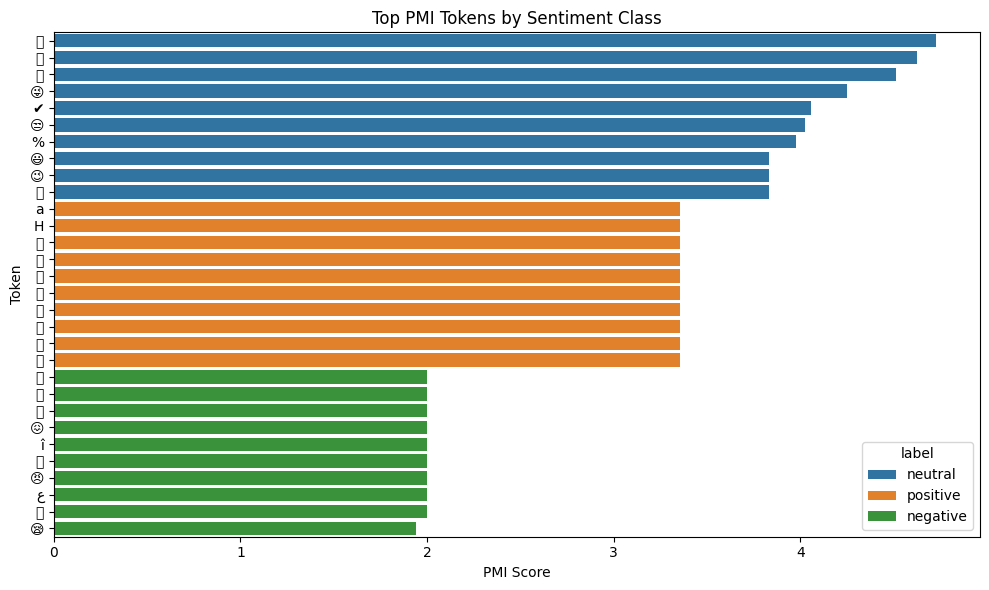

In [64]:
# Visualisations
!pip install nltk
!pip install matplotlib seaborn
import re
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")  # balanced sizing

# Filter noisy tokens for neater charts 
TOP_K_PLOT = 12        # how many bars per class to show
MIN_TOKEN_LEN = 3      # drop super-short items
EXCLUDE_PATTERNS = [r"^@", r"^#",
                    r"^https?://", r"\.com\b",  # urls
                    r"^\d+$"]                   # pure numbers

def looks_noisy(tok: str) -> bool:
    if tok is None: return True
    tok = str(tok).strip().lower()
    if len(tok) < MIN_TOKEN_LEN: return True
    if any(re.search(p, tok) for p in EXCLUDE_PATTERNS): return True
    return False

cands_clean = cands[~cands["token"].map(looks_noisy)].copy()

# NOTE: remove exact duplicates across classes keeping highest PMI
cands_clean = (cands_clean
               .sort_values("PMI", ascending=False)
               .drop_duplicates(subset=["token"], keep="first"))


# Ensure paths are defined
RESULTS = Path("results")
RESULTS.mkdir(exist_ok=True)

#Bar chart: Top PMI tokens by class
# Top 10 tokens by PMI per class
top_tokens = (
    best.sort_values("PMI", ascending=False)
    .groupby("label")
    .head(10)
    .reset_index(drop=True)
)
plt.figure(figsize=(10, 6))
sns.barplot(data=top_tokens, x="PMI", y="token", hue="label")
plt.title("Top PMI Tokens by Sentiment Class")
plt.xlabel("PMI Score")
plt.ylabel("Token")
plt.tight_layout()
plt.savefig(RESULTS / "fig_top_pmi_terms.png")
plt.show()

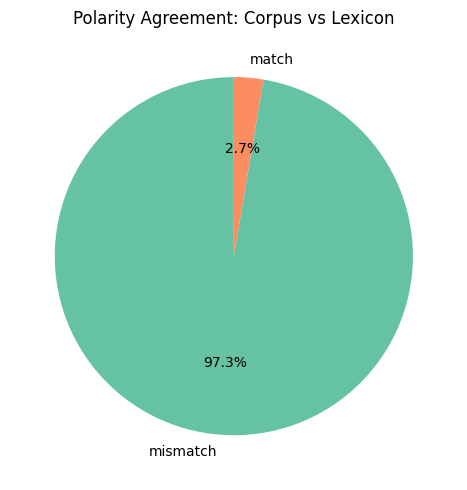

In [66]:
#Agreement Pie Chart
# Read match file (already created earlier by join logic)
pivot_path = RESULTS / "corpus_vs_lexicon_matches_enpivot.csv"
pivot_df = pd.read_csv(pivot_path)

# Count match vs mismatch
agree_counts = pivot_df["agreement"].value_counts()

# Plot
plt.figure(figsize=(5, 5))
agree_counts.plot.pie(autopct="%1.1f%%", startangle=90, colors=["#66c2a5", "#fc8d62"])
plt.title("Polarity Agreement: Corpus vs Lexicon")
plt.ylabel("")
plt.tight_layout()
plt.savefig(RESULTS / "fig_agreement_pie.png")
plt.show()

In [67]:
import pandas as pd
import string

rag_df = pd.read_csv(RESULTS / "rag_review_queue_enpivot.csv")

rag_clean = rag_df.copy()

# Drop NaN or punctuation-only tokens
rag_clean = rag_clean[rag_clean["token"].notna()]
rag_clean = rag_clean[~rag_clean["token"].isin(list(string.punctuation))]
rag_clean = rag_clean[~rag_clean["token"].astype(str).str.isnumeric()]

# 🚨 NEW: Drop single-character tokens (like A, B, C)
rag_clean = rag_clean[rag_clean["token"].astype(str).str.len() > 1]

# Keep only genuine mismatches
if "pmi_label" in rag_clean.columns and "lexicon_sign" in rag_clean.columns:
    rag_clean = rag_clean[rag_clean["pmi_label"] != rag_clean["lexicon_sign"]]

print(f"Original rows: {len(rag_df)} → Cleaned rows: {len(rag_clean)}")
display(rag_clean.head(10))

rag_clean.to_csv(RESULTS / "sample_disambiguation_cases_clean.csv", index=False)
print("Clean sample saved to sample_disambiguation_cases_clean.csv")


Original rows: 220 → Cleaned rows: 0


,token,token_en,pmi_label,lexicon_sign,contexts,llm_prompt


Clean sample saved to sample_disambiguation_cases_clean.csv


In [68]:
#Table view: Mismatches needing disambiguation
# Load RAG queue
rag_df = pd.read_csv(RESULTS / "rag_review_queue_enpivot.csv")

# Preview top few mismatches
display(rag_df.head(10))  # for report table

# Optionally save smaller sample
rag_df.head(20).to_csv(RESULTS / "sample_disambiguation_cases.csv", index=False)


,token,token_en,pmi_label,lexicon_sign,contexts,llm_prompt
0,,NaN,neutral,0,[],You are helping annotate a multilingual sentim...
1,!,NaN,neutral,0,[],You are helping annotate a multilingual sentim...
2,"""",NaN,neutral,0,[],You are helping annotate a multilingual sentim...
3,#,NaN,positive,0,[],You are helping annotate a multilingual sentim...
4,$,NaN,neutral,0,[],You are helping annotate a multilingual sentim...
5,%,NaN,neutral,0,[],You are helping annotate a multilingual sentim...
6,&,NaN,neutral,0,[],You are helping annotate a multilingual sentim...
7,',NaN,neutral,0,[],You are helping annotate a multilingual sentim...
8,(,NaN,neutral,0,[],You are helping annotate a multilingual sentim...
9,),NaN,neutral,0,[],You are helping annotate a multilingual sentim...


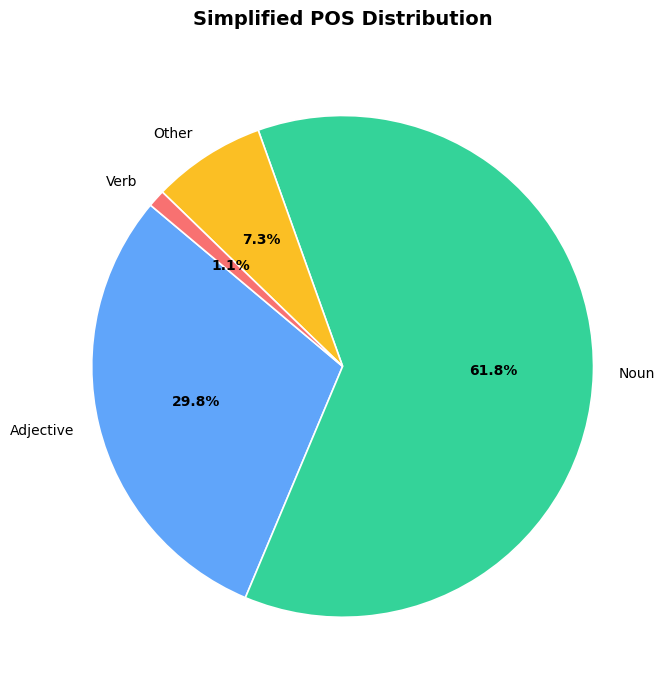

In [71]:
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
from nltk import pos_tag

# Simplify POS tags into broader categories 
pos_map = defaultdict(lambda: "Other", {
    "NN": "Noun", "NNS": "Noun", "NNP": "Noun",
    "VB": "Verb", "VBD": "Verb", "VBG": "Verb", "VBN": "Verb", "VBP": "Verb", "VBZ": "Verb",
    "JJ": "Adjective", "JJR": "Adjective", "JJS": "Adjective"
})

# Get simplified POS tags for top tokens
simplified_tags = [pos_map[tag] for _, tag in pos_tag(top_tokens)]
simple_counts = Counter(simplified_tags)

# Plot cleaner pie chart 
plt.figure(figsize=(7, 7))
colors = ["#60a5fa", "#34d399", "#fbbf24", "#f87171", "#a78bfa"]  # pastel blue/green/yellow/red/purple
wedges, texts, autotexts = plt.pie(
    simple_counts.values(),
    labels=simple_counts.keys(),
    autopct='%1.1f%%',
    startangle=140,
    colors=colors[:len(simple_counts)],
    wedgeprops={"edgecolor": "white", "linewidth": 1.2},
    textprops={'fontsize': 10, 'color': 'black'}
)

plt.setp(autotexts, size=10, weight="bold", color="black")
plt.title("Simplified POS Distribution", fontsize=14, weight="bold", pad=20)
plt.tight_layout()
plt.savefig(RESULTS / "fig_pos_piechart.png", dpi=150)
plt.show()


In [ ]:
""The cell below shows three visualisations but from the three we only need one which
#is the sentiment distribution of Top Tokens, if you are to re-run the translation you can delete the whole cell block (which is the one comment out)
#we kept it just so you can see the visual that we need. ""


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Saved figures → results
YES results\pmi_candidates.csv
YES results\pmi_terms_with_english.csv
YES results\corpus_vs_lexicon_matches_enpivot.csv
YES results\rag_review_queue_enpivot.csv
YES results\fig_top_pmi_terms.png
YES results\fig_agreement_pie.png


C:\Users\Busisiwe\AppData\Local\Temp\ipykernel_23212\3768558407.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=merged_en, x="label", order=["positive", "neutral", "negative"], palette="pastel")


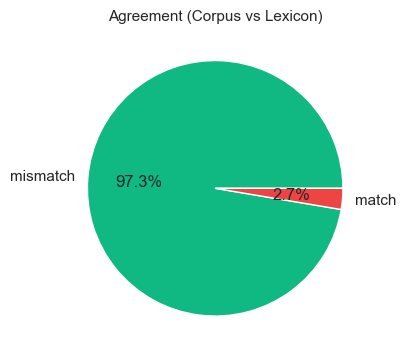

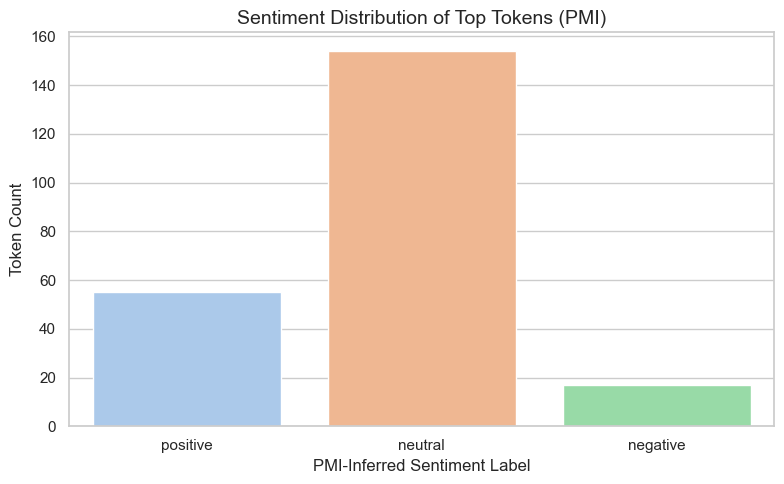

C:\Users\Busisiwe\AppData\Local\Temp\ipykernel_23212\3768558407.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_mismatches.index, x=top_mismatches.values, palette="flare")


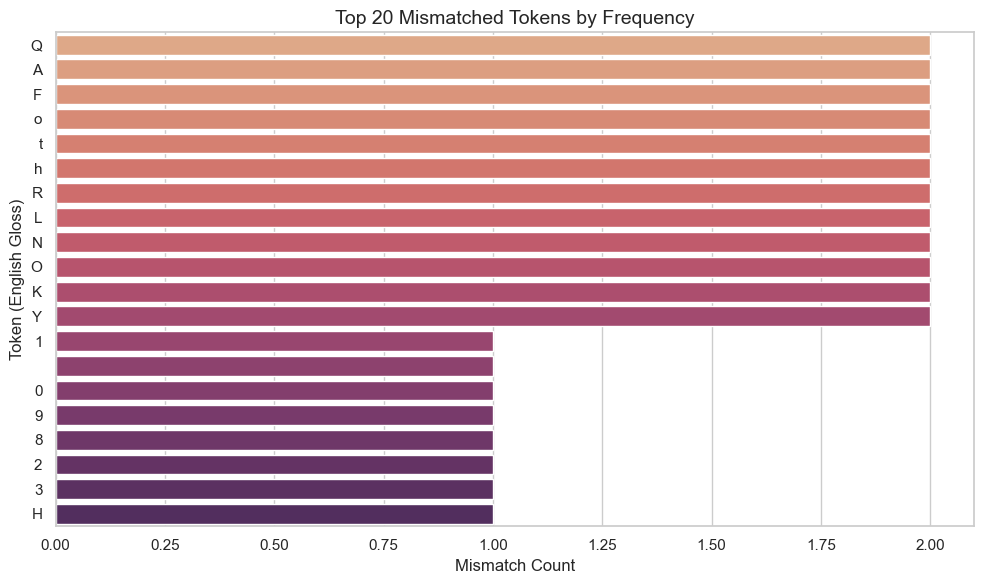

,token,token_en,pmi_label,lexicon_sign,contexts,llm_prompt
0,,NaN,neutral,0,\n•,"You are helping annotate a multilingual sentiment lexicon.\nWord: \nLanguage: Shona\nEnglish gloss: nan\nCorpus sentiment trend (from PMI): neutral.\nLexicon polarity sign: 0 (−1=neg,0=neu,1=pos).\nTasks: (1) Provide POS tag; (2) Decide polarity (−9..9) and label (neg/neu/pos); (3) If ambiguous, explain briefly and give two example sentences."
1,!,NaN,neutral,0,\n•,"You are helping annotate a multilingual sentiment lexicon.\nWord: !\nLanguage: Shona\nEnglish gloss: nan\nCorpus sentiment trend (from PMI): neutral.\nLexicon polarity sign: 0 (−1=neg,0=neu,1=pos).\nTasks: (1) Provide POS tag; (2) Decide polarity (−9..9) and label (neg/neu/pos); (3) If ambiguous, explain briefly and give two example sentences."


In [40]:
""""#  Cell J: Plots (top-K bars and pie chart)
# !pip install matplotlib seaborn
# import re
# import matplotlib.pyplot as plt
# import seaborn as sns

# sns.set_theme(style="whitegrid", context="notebook")  # balanced sizing

# # ===Filter noisy tokens for neater charts ===
# TOP_K_PLOT = 12        # how many bars per class to show
# MIN_TOKEN_LEN = 3      # drop super-short items
# EXCLUDE_PATTERNS = [r"^@", r"^#",
#                     r"^https?://", r"\.com\b",  # urls
#                     r"^\d+$"]                   # pure numbers

# def looks_noisy(tok: str) -> bool:
#     if tok is None: return True
#     tok = str(tok).strip().lower()
#     if len(tok) < MIN_TOKEN_LEN: return True
#     if any(re.search(p, tok) for p in EXCLUDE_PATTERNS): return True
#     return False

# cands_clean = cands[~cands["token"].map(looks_noisy)].copy()

# # NOTE: remove exact duplicates across classes keeping highest PMI
# cands_clean = (cands_clean
#                .sort_values("PMI", ascending=False)
#                .drop_duplicates(subset=["token"], keep="first"))

# # === Bar charts: top-K per label (negative / neutral / positive) ===
# # labels_in_order = ["negative", "neutral", "positive"]  # keeps columns aligned visually
# # fig, axes = plt.subplots(1, len(labels_in_order), figsize=(14, 4), sharey=True)

# # for ax, lbl in zip(axes, labels_in_order):
# #     sub = cands_clean[cands_clean["label"] == lbl]
# #     top = sub.nlargest(TOP_K_PLOT, "PMI").iloc[::-1]  # reverse so biggest is at top
# #     sns.barplot(data=top, x="PMI", y="token", ax=ax, color="#3b82f6")
# #     ax.set_title(f"Top PMI: {lbl}", fontsize=11)
# #     ax.set_xlabel("PMI", fontsize=10)
# #     ax.set_ylabel("token" if ax is axes[0] else "")
# #     # smaller ticklabels to avoid overlap
# #     ax.tick_params(axis="y", labelsize=8)
# #     ax.tick_params(axis="x", labelsize=8)

# # plt.tight_layout()
# # plt.subplots_adjust(left=0.22)  # more room for token labels
# # plt.savefig(RESULTS / "fig_top_pmi_terms.png", dpi=150)

# #  ===Agreement pie (match vs mismatch)===
# try:
#     counts = merged_en["agreement"].value_counts(dropna=False)
#     plt.figure(figsize=(4.2, 4.2))
#     plt.pie(counts.values,
#             labels=counts.index.astype(str),
#             autopct="%1.1f%%",
#             colors=["#10b981", "#ef4444", "#9ca3af"])
#     plt.title("Agreement (Corpus vs Lexicon)", fontsize=11)
#     plt.tight_layout()
#     plt.savefig(RESULTS / "fig_agreement_pie.png", dpi=150)
#     print("Saved figures →", RESULTS)
# except Exception as e:
#     print("Skipping pie chart (need merged_en):", e)

# # Deliverables :
# for p in [
#     RESULTS/"pmi_candidates.csv",
#     RESULTS/"pmi_terms_with_english.csv",
#     RESULTS/"corpus_vs_lexicon_matches_enpivot.csv",
#     RESULTS/"rag_review_queue_enpivot.csv",
#     RESULTS/"fig_top_pmi_terms.png",
#     RESULTS/"fig_agreement_pie.png",
# ]:
#     print(("YES" if p.exists() else "NO"), p)

# import seaborn as sns
# import matplotlib.pyplot as plt

# # Plot sentiment distribution of tokens by PMI
# sns.set(style="whitegrid")
# plt.figure(figsize=(8, 5))
# sns.countplot(data=merged_en, x="label", order=["positive", "neutral", "negative"], palette="pastel")
# plt.title("Sentiment Distribution of Top Tokens (PMI)", fontsize=14)
# plt.xlabel("PMI-Inferred Sentiment Label")
# plt.ylabel("Token Count")
# plt.tight_layout()
# plt.show()

# #Top token with mismatches# Filter mismatches and count most common tokens
# top_mismatches = (merged_en[merged_en["agreement"] == "mismatch"]
#                     .groupby("token_en")
#                     .size()
#                     .sort_values(ascending=False)
#                     .head(20))

# plt.figure(figsize=(10, 6))
# sns.barplot(y=top_mismatches.index, x=top_mismatches.values, palette="flare")
# plt.title("Top 20 Mismatched Tokens by Frequency", fontsize=14)
# plt.xlabel("Mismatch Count")
# plt.ylabel("Token (English Gloss)")
# plt.tight_layout()
# plt.show()


# import pandas as pd

# # Load the RAG-based review prompts
# rag_df = pd.read_csv("results/rag_review_queue_enpivot.csv")

# # Display 2 sample mismatches that were reviewed via LLM
# sample = rag_df.head(2).copy()

# # Clean context display
# sample["contexts"] = sample["contexts"].apply(lambda x: "\n• " + "\n• ".join(eval(x)) if pd.notna(x) else "")

# # Keep only relevant columns
# cols = ["token", "token_en", "pmi_label", "lexicon_sign", "contexts", "llm_prompt"]
# example_table = sample[cols]

# # Format and print as readable table
# pd.set_option('display.max_colwidth', None)
# display(example_table)


# # !pip install plotly
# # import plotly.graph_objects as go

# # # Use only two examples
# # table_data = sample[["token", "token_en", "pmi_label", "lexicon_sign", "contexts"]]

# # fig = go.Figure(data=[go.Table(
# #     columnwidth=[60, 80, 80, 80, 200],
# #     header=dict(values=["Token", "English Gloss", "PMI Label", "Lexicon Polarity", "Example Contexts"],
# #                 fill_color="#0f2537", font=dict(color="white", size=12), align="left"),
# #     cells=dict(values=[table_data[col] for col in table_data.columns],
# #                fill_color="lavender", align="left"))
# # ])
# # fig.update_layout(title="Disambiguation via LLM: Sample Examples", height=400)
# # fig.show()"""



In [ ]:
import sys
!{sys.executable} -m pip install googletrans==4.0.0rc1 httpx==0.13.3 httpcore==0.9.1 textblob==0.17.1